In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf

from tensorflow.keras.models import load_model

In [2]:
# Define the project root directory.
# In this notebook, the current working directory is the src folder,
# so the parent directory is the main project folder.
PROJECT_ROOT = Path.cwd().parent


# Define the directory containing processed data
PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)


# Define the directory used to store trained models
MODEL_DIR = (
    PROJECT_ROOT
    / "models"
)


# Define the main results directory
RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
)


# Define a separate folder for Grad-CAM output images
GRADCAM_DIR = (
    RESULTS_DIR
    / "gradcam"
)


# Create the Grad-CAM directory if it does not already exist
# parents=True also creates any missing parent folders
# exist_ok=True prevents an error if the folder already exists
GRADCAM_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [3]:
# Load the MRI metadata containing the
# train, validation, and test split information
df = pd.read_csv(
    PROCESSED_DIR
    / "mri_metadata_split.csv"
)

# Check whether a numeric label column is already present
if "label" not in df.columns:

    # Define the mapping from class names
    # to binary numeric labels
    label_map = {
        "control": 0,
        "parkinsons": 1
    }

    # Create the label column from the class column
    df["label"] = (
        df["class"]
        .map(label_map)
    )

In [4]:
# Select only the rows that belong to the
# test split of the MRI dataset
test_df = (
    df[
        df["split"] == "test"
    ]

    # Reset the row index so it runs from
    # 0 to the number of test images minus 1
    .reset_index(drop=True)
)

# Display the total number of MRI images
# contained in the test dataset
print(
    "Test images:",
    len(test_df)
)

Test images: 385


In [5]:
# Define the path to the saved
# fine-tuned EfficientNetB0 model
MODEL_FILE = (
    MODEL_DIR
    / "efficientnet_finetuned.keras"
)

# Load the complete trained Keras model
# from the saved .keras file
model = load_model(
    MODEL_FILE
)

In [6]:
# Display a summary of the loaded fine-tuned
# EfficientNetB0 model architecture
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,534,184 (28.74 MB)

 Trainable params: 1,660,257 (6.33 MB)

 Non-trainable params: 2,553,411 (9.74 MB)

 Optimizer params: 3,320,516 (12.67 MB)

In [7]:
# Loop through every top-level layer in the loaded model
# and display its index, name, and layer type
for i, layer in enumerate(
    model.layers
):
    print(
        # Position of the layer in the model
        i,

        # Keras name assigned to the layer
        layer.name,

        # Type of Keras layer, such as Dense,
        # Dropout, Sequential, or Functional
        type(layer).__name__
    )

0 sequential Sequential
1 efficientnetb0 Functional
2 global_average_pooling2d GlobalAveragePooling2D
3 dense Dense
4 dropout Dropout
5 dense_1 Dense


In [8]:
# Start with no EfficientNetB0 base model selected
base_model = None

# Loop through each top-level layer
# in the loaded fine-tuned model
for layer in model.layers:

    # Look for the layer whose name contains
    # "efficientnet"
    if "efficientnet" in layer.name.lower():

        # Save the EfficientNetB0 base model
        base_model = layer

        # Stop searching once it has been found
        break


# Display the EfficientNetB0 base model
print(
    base_model
)

<Functional name=efficientnetb0, built=True>


In [9]:
# Search backwards through the EfficientNetB0 layers
# to find the final layer that still produces
# a 4-dimensional feature map
for layer in reversed(
    base_model.layers
):

    try:

        # Get the output shape of the current layer
        output_shape = (
            layer.output.shape
        )

        # Grad-CAM needs a convolutional feature map,
        # which normally has 4 dimensions:
        # (batch, height, width, channels)
        if len(output_shape) == 4:

            # Display the first suitable layer found
            # when searching from the end of the model
            print(
                "Last 4D layer:",
                layer.name,
                output_shape
            )

            # Stop once the final 4D layer has been found
            break

    # Skip any layer where the output shape
    # cannot be inspected safely
    except Exception:
        continue

Last 4D layer: top_activation (None, 7, 7, 1280)


In [11]:
# Store the name of the final 4D feature-map layer
# that was identified in the previous search
LAST_CONV_LAYER_NAME = (
    layer.name
)

# Display the selected layer name
print(
    LAST_CONV_LAYER_NAME
)

top_activation


In [12]:
# Set the height that each MRI image will be resized to
IMG_HEIGHT = 224

# Set the width that each MRI image will be resized to
IMG_WIDTH = 224

In [13]:
# Define a function to load and preprocess
# one MRI image for the EfficientNetB0 model
def load_image_for_model(
    file_path
):

    # Read the image file from disk
    image = tf.io.read_file(
        str(file_path)
    )

    # Decode the PNG as a single-channel
    # grayscale image
    image = tf.image.decode_png(
        image,
        channels=1
    )

    # Convert the image to float32 values
    # scaled between 0 and 1
    image = tf.image.convert_image_dtype(
        image,
        tf.float32
    )

    # Resize the image to the dimensions
    # expected by the trained model
    image = tf.image.resize(
        image,
        [
            IMG_HEIGHT,
            IMG_WIDTH
        ]
    )

    # Convert the single grayscale channel
    # into three identical RGB channels
    image = tf.image.grayscale_to_rgb(
        image
    )

    # Return the processed image
    return image

In [14]:
# Select the first Parkinson's MRI slice
# from the test dataset
sample_row = (
    test_df[
        test_df["class"]
        == "parkinsons"
    ]
    .iloc[0]
)

# Get the file path of the selected
# processed MRI image
image_path = (
    sample_row[
        "processed_file"
    ]
)

# Display identifying information
# about the selected test image
print(
    sample_row[
        [
            "subject_id",
            "class",
            "slice_index"
        ]
    ]
)

subject_id     PPMI_3330_NM_Reconstructed_DaTSCAN_Br_20130321...
class                                                 parkinsons
slice_index                                                   35
Name: 195, dtype: object


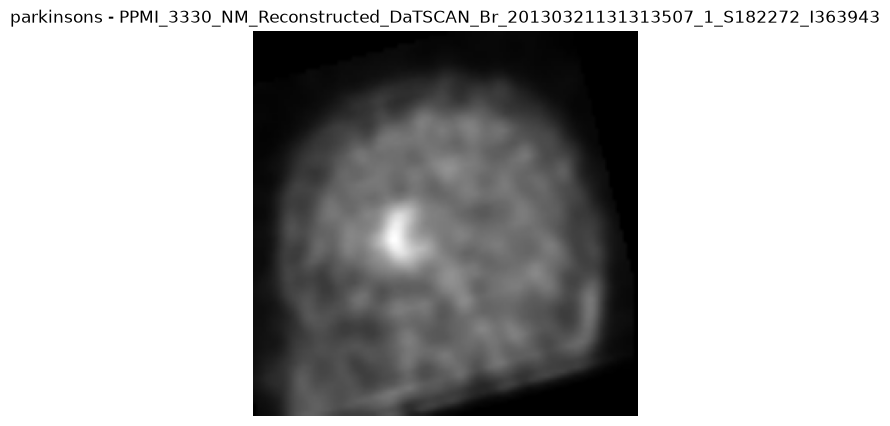

In [15]:
# Load the selected MRI slice and preprocess it
# using the same function prepared for the model
image = load_image_for_model(
    image_path
)

# Create a figure for displaying the MRI image
plt.figure(
    figsize=(5, 5)
)

# Display the processed MRI image
plt.imshow(
    image.numpy()
)

# Add the class and subject ID to the image title
plt.title(
    f"{sample_row['class']} "
    f"- {sample_row['subject_id']}"
)

# Hide the axis markings for a cleaner image
plt.axis("off")

# Display the MRI image
plt.show()

In [16]:
# Add a batch dimension to the MRI image
# so its shape changes from:
# (224, 224, 3) -> (1, 224, 224, 3)
input_image = tf.expand_dims(
    image,
    axis=0
)

# Use the trained EfficientNetB0 model
# to predict the Parkinson's probability
probability = (
    model.predict(
        input_image,

        # Suppress prediction progress output
        verbose=0
    )[0][0]
)

# Display the predicted Parkinson's probability
# rounded to four decimal places
print(
    f"Parkinson's probability: "
    f"{probability:.4f}"
)

Parkinson's probability: 0.4967


In [17]:
# Convert the predicted probability into
# a readable class label using a 0.5 threshold
prediction = (
    "parkinsons"
    if probability >= 0.5
    else "control"
)

# Display the class predicted by the model
print(
    "Predicted:",
    prediction
)

# Display the true class from the metadata
# so the prediction can be checked against it
print(
    "Actual:",
    sample_row["class"]
)

Predicted: control
Actual: parkinsons


In [18]:
# Retrieve the final convolutional-style feature-map layer
# from the EfficientNetB0 base model
last_conv_layer = (
    base_model.get_layer(
        LAST_CONV_LAYER_NAME
    )
)

In [19]:
# Create a new model that takes the same input
# as the EfficientNetB0 base model
feature_model = tf.keras.Model(
    inputs=base_model.input,

    # Output the feature maps produced by the
    # selected final convolutional layer
    outputs=last_conv_layer.output
)

In [20]:
# Get all layers in the full model that come
# after the EfficientNetB0 base model
classifier_layers = (
    model.layers[
        model.layers.index(base_model) + 1:
    ]
)

In [21]:
# Loop through each classifier layer that comes
# after the EfficientNetB0 base model
for layer in classifier_layers:

    # Display the name of the current classifier layer
    print(
        layer.name
    )

global_average_pooling2d
dense
dropout
dense_1


In [22]:
# Define a function that generates a Grad-CAM heatmap
# for a single MRI image
def make_gradcam_heatmap(
    image_tensor,
    full_model,
    base_model,
    last_conv_layer_name
):

    # Retrieve the selected final convolutional
    # feature-map layer from EfficientNetB0
    last_conv_layer = (
        base_model.get_layer(
            last_conv_layer_name
        )
    )

    # Create a temporary model that returns:
    # 1. the selected convolutional feature maps
    # 2. the normal output from EfficientNetB0
    grad_model = tf.keras.Model(
        inputs=base_model.inputs,
        outputs=[
            last_conv_layer.output,
            base_model.output
        ]
    )

    # Record the operations needed to calculate
    # how the prediction changes with the feature maps
    with tf.GradientTape() as tape:

        # Pass the MRI image through EfficientNetB0
        # and collect both outputs
        conv_outputs, base_outputs = (
            grad_model(
                image_tensor,
                training=False
            )
        )

        # Start with the output from EfficientNetB0
        x = base_outputs

        # Find the position of the EfficientNetB0
        # base model inside the complete model
        start_index = (
            full_model.layers.index(
                base_model
            )
            + 1
        )

        # Pass the EfficientNetB0 output through
        # the remaining classifier layers
        for layer in (
            full_model.layers[
                start_index:
            ]
        ):

            x = layer(
                x,
                training=False
            )

        # Select the final Parkinson's probability
        prediction = x[:, 0]

    # Calculate the gradients of the Parkinson's
    # prediction with respect to the convolutional features
    grads = tape.gradient(
        prediction,
        conv_outputs
    )

    # Average the gradients across the batch,
    # height, and width dimensions
    # to obtain one importance weight per feature channel
    pooled_grads = (
        tf.reduce_mean(
            grads,
            axis=(
                0,
                1,
                2
            )
        )
    )

    # Remove the batch dimension from
    # the convolutional feature maps
    conv_outputs = (
        conv_outputs[0]
    )

    # Weight each feature map by its importance
    # and combine them into one Grad-CAM heatmap
    heatmap = (
        conv_outputs
        @ pooled_grads[..., tf.newaxis]
    )

    # Remove unnecessary dimensions
    heatmap = (
        tf.squeeze(
            heatmap
        )
    )

    # Keep only positive contributions to
    # the Parkinson's prediction
    heatmap = tf.maximum(
        heatmap,
        0
    )

    # Find the largest heatmap value
    max_value = (
        tf.reduce_max(
            heatmap
        )
    )

    # Normalise the heatmap to values between 0 and 1
    if max_value > 0:

        heatmap = (
            heatmap
            / max_value
        )

    # Convert the TensorFlow tensor to a NumPy array
    # so it can be visualised with Matplotlib
    return heatmap.numpy()

In [23]:
# Generate a Grad-CAM heatmap for the
# selected MRI image
heatmap = make_gradcam_heatmap(
    # MRI image with batch dimension:
    # (1, 224, 224, 3)
    input_image,

    # Complete fine-tuned classification model
    model,

    # Embedded EfficientNetB0 base model
    base_model,

    # Name of the final convolutional-style
    # feature-map layer selected earlier
    LAST_CONV_LAYER_NAME
)

In [24]:
# Display the dimensions of the generated Grad-CAM heatmap
print(
    heatmap.shape
)

# Display the minimum and maximum heatmap values
# to confirm that the heatmap has been normalised
print(
    heatmap.min(),
    heatmap.max()
)

(7, 7)
0.0 1.0


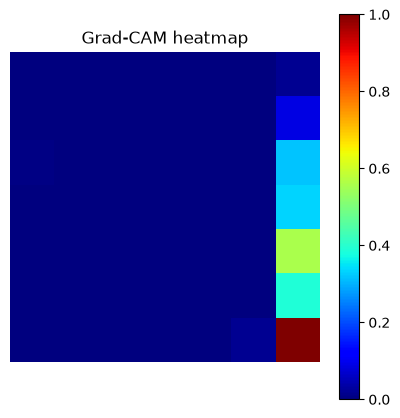

In [25]:
# Create a figure to display the Grad-CAM heatmap
plt.figure(
    figsize=(5, 5)
)

# Display the heatmap using the "jet" colour map
# so low and high activation areas are easier to distinguish
plt.imshow(
    heatmap,
    cmap="jet"
)

# Add a colour scale showing the
# relative Grad-CAM activation values
plt.colorbar()

# Add a title to the heatmap
plt.title(
    "Grad-CAM heatmap"
)

# Hide the axis markings for a cleaner visualisation
plt.axis("off")

# Display the Grad-CAM heatmap
plt.show()

In [26]:
# Resize the Grad-CAM heatmap so it matches
# the original MRI image dimensions
heatmap_resized = (
    tf.image.resize(

        # Add a temporary channel dimension so TensorFlow
        # can resize the 2D heatmap as an image
        heatmap[
            ...,
            np.newaxis
        ],

        # Resize to the same height and width
        # used by the EfficientNetB0 input image
        [
            IMG_HEIGHT,
            IMG_WIDTH
        ]
    )

    # Convert the TensorFlow tensor to a NumPy array
    .numpy()

    # Remove the temporary single-channel dimension
    .squeeze()
)

In [27]:
# Convert the processed MRI image from a
# TensorFlow tensor into a NumPy array
original_image = (
    image.numpy()
)

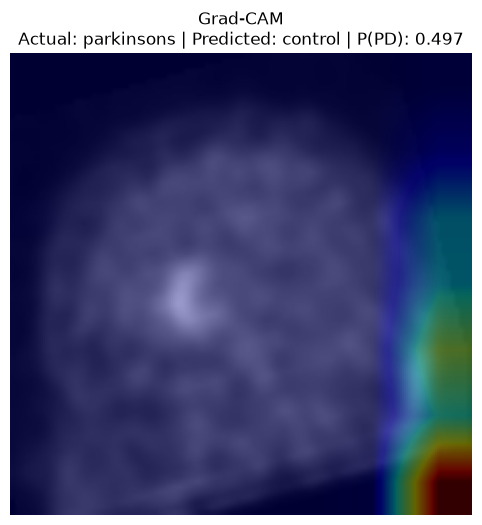

In [28]:
# Create a figure for displaying the MRI image
# with the Grad-CAM heatmap overlaid on top
plt.figure(
    figsize=(6, 6)
)

# Display the original MRI image
plt.imshow(
    original_image
)

# Overlay the resized Grad-CAM heatmap
# using the "jet" colour map and partial transparency
plt.imshow(
    heatmap_resized,
    cmap="jet",
    alpha=0.4
)

# Add a title showing:
# - the true class
# - the model's predicted class
# - the predicted Parkinson's probability
plt.title(
    f"Grad-CAM\n"
    f"Actual: {sample_row['class']} | "
    f"Predicted: {prediction} | "
    f"P(PD): {probability:.3f}"
)

# Hide axis labels and tick marks
plt.axis("off")

# Display the final Grad-CAM overlay
plt.show()

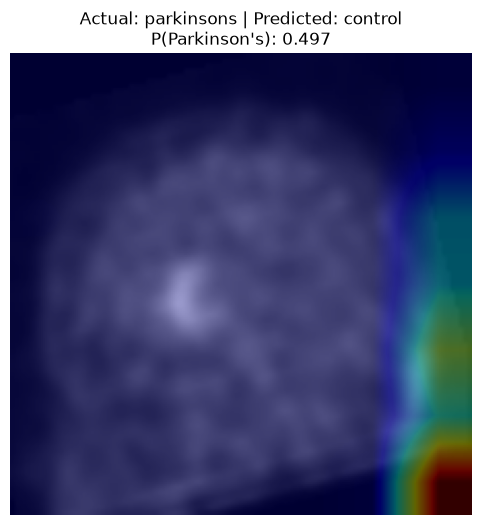

/Users/paulcollingwood/Documents/Source/parkinsons_ml/results/gradcam/PPMI_3330_NM_Reconstructed_DaTSCAN_Br_20130321131313507_1_S182272_I363943_z35_gradcam.png


In [29]:
# Create a filename for the Grad-CAM image
# using the subject ID and MRI slice number
output_file = (
    GRADCAM_DIR
    / (
        f"{sample_row['subject_id']}"
        f"_z{sample_row['slice_index']}"
        "_gradcam.png"
    )
)

# Create a figure for the saved Grad-CAM overlay
plt.figure(
    figsize=(6, 6)
)

# Display the original MRI image
plt.imshow(
    original_image
)

# Overlay the resized Grad-CAM heatmap
# with partial transparency
plt.imshow(
    heatmap_resized,
    cmap="jet",
    alpha=0.4
)

# Add the actual class, predicted class,
# and Parkinson's probability to the title
plt.title(
    f"Actual: {sample_row['class']} | "
    f"Predicted: {prediction}\n"
    f"P(Parkinson's): "
    f"{probability:.3f}"
)

# Hide the axis for a cleaner image
plt.axis("off")

# Save the Grad-CAM image at high resolution
plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

# Display the saved Grad-CAM image
plt.show()

# Display the path of the saved image file
print(
    output_file
)

In [30]:
# Define a function that loads and prepares
# every processed MRI image in a DataFrame
# for prediction with the trained model
def create_prediction_dataset(
    dataframe
):

    # Create an empty list to store
    # the processed image tensors
    images = []

    # Loop through every processed MRI image path
    # stored in the DataFrame
    for file_path in (
        dataframe[
            "processed_file"
        ]
    ):

        # Load and preprocess the current image
        # using the same function used for model input
        image = (
            load_image_for_model(
                file_path
            )
        )

        # Add the processed image tensor
        # to the list
        images.append(
            image
        )

    # Combine all individual image tensors
    # into one larger tensor with shape:
    # (number_of_images, 224, 224, 3)
    return tf.stack(
        images
    )

In [31]:
# Create a tensor containing all MRI images
# from the test DataFrame
test_images = (
    create_prediction_dataset(
        test_df
    )
)

In [32]:
# Use the trained fine-tuned model to predict
# Parkinson's probabilities for all test MRI slices
test_probabilities = (
    model.predict(
        test_images,

        # Display prediction progress
        verbose=1
    )

    # Convert the output from shape (n, 1)
    # into a one-dimensional NumPy array
    .flatten()
)

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 181ms/step


In [33]:
# Create a copy of the test DataFrame
# so the original test data remains unchanged
gradcam_df = (
    test_df.copy()
)

# Add the predicted Parkinson's probability
# for each MRI slice
gradcam_df[
    "probability"
] = (
    test_probabilities
)

# Convert the probabilities into binary predictions
# using 0.5 as the classification threshold
gradcam_df[
    "prediction"
] = (
    gradcam_df[
        "probability"
    ]

    # Probability >= 0.5 is classified as Parkinson's
    >= 0.5
).astype(int)

In [34]:
# Convert the numeric prediction values
# into readable class names
gradcam_df[
    "predicted_class"
] = (
    gradcam_df[
        "prediction"
    ]

    # Map 0 and 1 to the corresponding class labels
    .map({
        0: "control",
        1: "parkinsons"
    })
)

In [35]:
# Select MRI slices that are actual Parkinson's cases
# and were also correctly predicted as Parkinson's
correct_pd = (
    gradcam_df[
        (
            # True class is Parkinson's
            gradcam_df["class"]
            == "parkinsons"
        )
        &
        (
            # Predicted class is also Parkinson's
            gradcam_df[
                "predicted_class"
            ]
            == "parkinsons"
        )
    ]
)


In [36]:
# Select MRI slices that are actual control cases
# and were also correctly predicted as control
correct_control = (
    gradcam_df[
        (
            # True class is control
            gradcam_df["class"]
            == "control"
        )
        &
        (
            # Predicted class is also control
            gradcam_df[
                "predicted_class"
            ]
            == "control"
        )
    ]
)

In [37]:
# Select MRI slices that are actual control cases
# but were incorrectly predicted as Parkinson's
false_positive = (
    gradcam_df[
        (
            # True class is control
            gradcam_df["class"]
            == "control"
        )
        &
        (
            # Predicted class is Parkinson's
            gradcam_df[
                "predicted_class"
            ]
            == "parkinsons"
        )
    ]
)

In [38]:
# Select MRI slices that are actual Parkinson's cases
# but were incorrectly predicted as control
false_negative = (
    gradcam_df[
        (
            # True class is Parkinson's
            gradcam_df["class"]
            == "parkinsons"
        )
        &
        (
            # Predicted class is control
            gradcam_df[
                "predicted_class"
            ]
            == "control"
        )
    ]
)

In [39]:
# Display the number of correctly classified
# Parkinson's MRI slices
print(
    "Correct Parkinson's:",
    len(correct_pd)
)

# Display the number of correctly classified
# control MRI slices
print(
    "Correct controls:",
    len(correct_control)
)

# Display the number of control slices that
# were incorrectly predicted as Parkinson's
print(
    "False positives:",
    len(false_positive)
)

# Display the number of Parkinson's slices that
# were incorrectly predicted as control
print(
    "False negatives:",
    len(false_negative)
)

Correct Parkinson's: 0
Correct controls: 195
False positives: 0
False negatives: 190


In [40]:
# Define a reusable function for displaying
# a Grad-CAM overlay for one MRI slice
def show_gradcam(
    row
):

    # Load and preprocess the MRI image
    image = (
        load_image_for_model(
            row[
                "processed_file"
            ]
        )
    )

    # Add a batch dimension so the image
    # can be passed into the model
    input_image = (
        tf.expand_dims(
            image,
            axis=0
        )
    )

    # Predict the Parkinson's probability
    # for this MRI slice
    probability = (
        model.predict(
            input_image,
            verbose=0
        )[0][0]
    )

    # Convert the probability into
    # a readable predicted class
    prediction = (
        "parkinsons"
        if probability >= 0.5
        else "control"
    )

    # Generate the Grad-CAM heatmap
    # for the selected MRI image
    heatmap = (
        make_gradcam_heatmap(
            input_image,
            model,
            base_model,
            LAST_CONV_LAYER_NAME
        )
    )

    # Resize the small Grad-CAM heatmap
    # to match the 224 x 224 MRI image
    heatmap_resized = (
        tf.image.resize(
            heatmap[
                ...,
                np.newaxis
            ],
            [
                IMG_HEIGHT,
                IMG_WIDTH
            ]
        )
        .numpy()
        .squeeze()
    )

    # Create a figure for the Grad-CAM overlay
    plt.figure(
        figsize=(6, 6)
    )

    # Display the original MRI image
    plt.imshow(
        image.numpy()
    )

    # Overlay the Grad-CAM heatmap
    # using partial transparency
    plt.imshow(
        heatmap_resized,
        cmap="jet",
        alpha=0.4
    )

    # Display the actual class,
    # predicted class, and Parkinson's probability
    plt.title(
        f"Actual: {row['class']}\n"
        f"Predicted: {prediction}\n"
        f"P(PD): {probability:.3f}"
    )

    # Hide axis labels and tick marks
    plt.axis("off")

    # Display the final Grad-CAM visualisation
    plt.show()

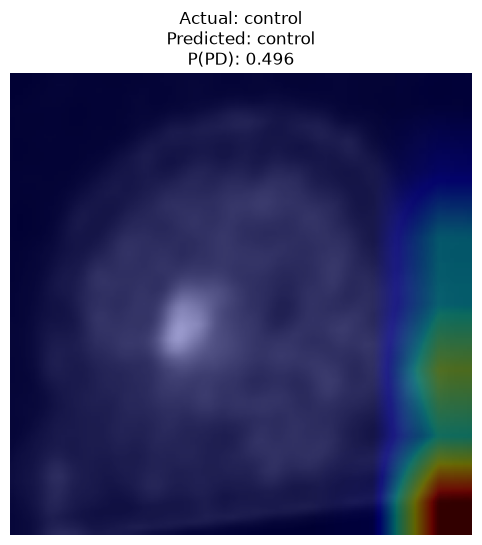

In [41]:
# Check that at least one correctly classified
# control MRI slice is available
if len(correct_control) > 0:

    # Display a Grad-CAM overlay for the
    # first correctly classified control example
    show_gradcam(
        correct_control.iloc[0]
    )

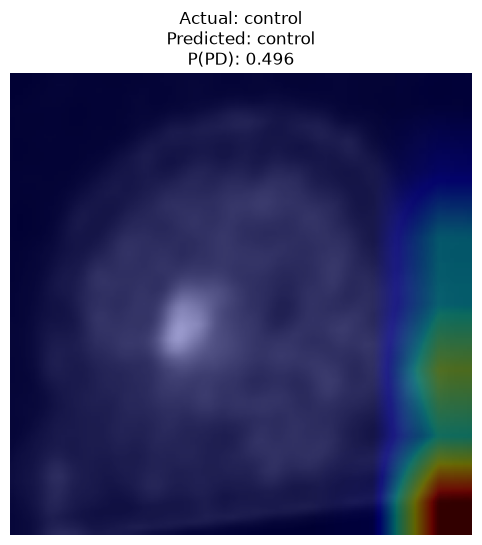

In [42]:
# Check that at least one correctly classified
# control MRI slice is available
if len(correct_control) > 0:

    # Display the Grad-CAM visualisation for the
    # first correctly classified control example
    show_gradcam(
        correct_control.iloc[0]
    )

In [43]:
# Check that at least one false-positive
# MRI slice is available
if len(false_positive) > 0:

    # Display the Grad-CAM visualisation for the
    # first control image incorrectly predicted
    # as Parkinson's
    show_gradcam(
        false_positive.iloc[0]
    )

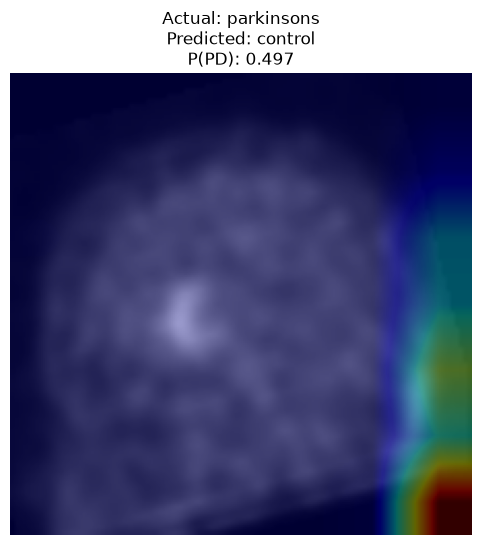

In [44]:
# Check that at least one false-negative
# MRI slice is available
if len(false_negative) > 0:

    # Display the Grad-CAM visualisation for the
    # first Parkinson's image incorrectly predicted
    # as control
    show_gradcam(
        false_negative.iloc[0]
    )

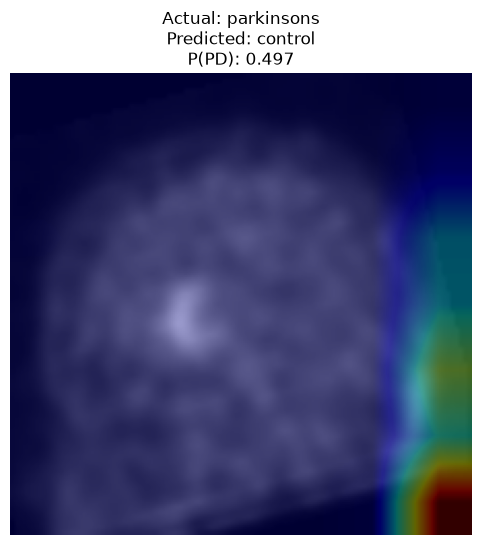

In [45]:
# Check that at least one false-negative
# MRI slice is available
if len(false_negative) > 0:

    # Display the Grad-CAM visualisation for the
    # first Parkinson's image incorrectly predicted
    # as control
    show_gradcam(
        false_negative.iloc[0]
    )

In [46]:
# Select the subject ID from the first row
# of the test dataset
subject_id = (
    test_df[
        "subject_id"
    ]
    .iloc[0]
)

In [47]:
# Select all Grad-CAM result rows that belong
# to the chosen subject
subject_rows = (
    gradcam_df[
        gradcam_df[
            "subject_id"
        ]
        == subject_id
    ]

    # Sort the subject's MRI slices by slice index
    # so they appear in anatomical order
    .sort_values(
        "slice_index"
    )
)

# Display the key information for each
# MRI slice belonging to this subject
subject_rows[
    [
        "subject_id",
        "slice_index",
        "class",
        "probability"
    ]
]

,subject_id,slice_index,class,probability
0,PPMI_3563_NM_Reconstructed_DaTSCAN_Br_20121011...,35,control,0.495872
1,PPMI_3563_NM_Reconstructed_DaTSCAN_Br_20121011...,40,control,0.496688
2,PPMI_3563_NM_Reconstructed_DaTSCAN_Br_20121011...,45,control,0.498271
3,PPMI_3563_NM_Reconstructed_DaTSCAN_Br_20121011...,50,control,0.496316
4,PPMI_3563_NM_Reconstructed_DaTSCAN_Br_20121011...,55,control,0.496121


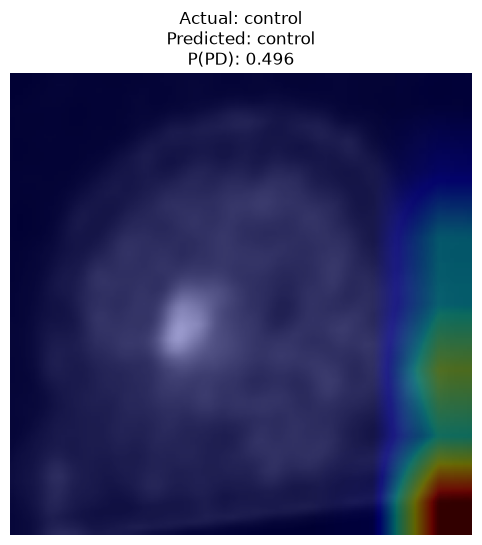

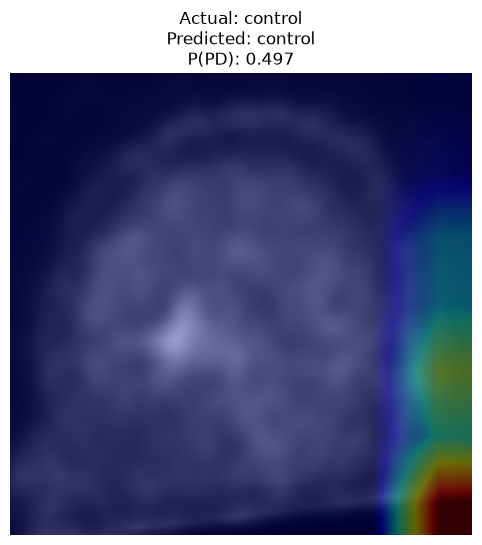

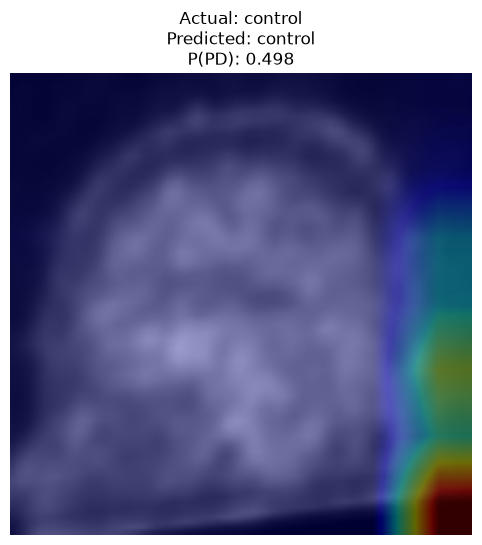

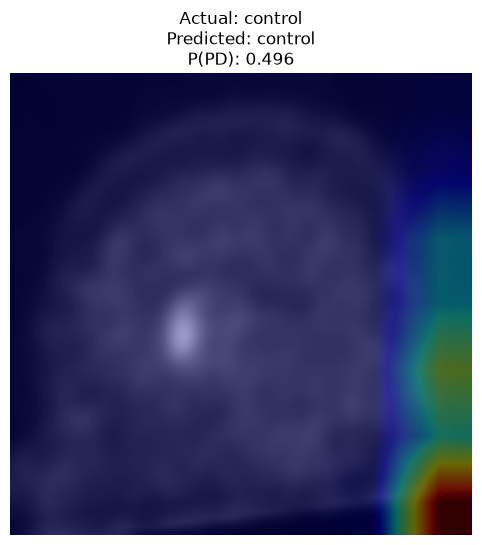

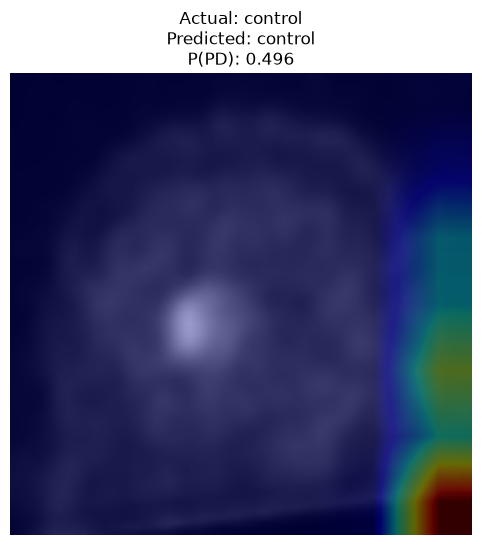

In [48]:
# Loop through every MRI slice belonging
# to the selected subject
for _, row in (
    subject_rows.iterrows()
):

    # Generate and display the Grad-CAM
    # visualisation for the current slice
    show_gradcam(
        row
    )